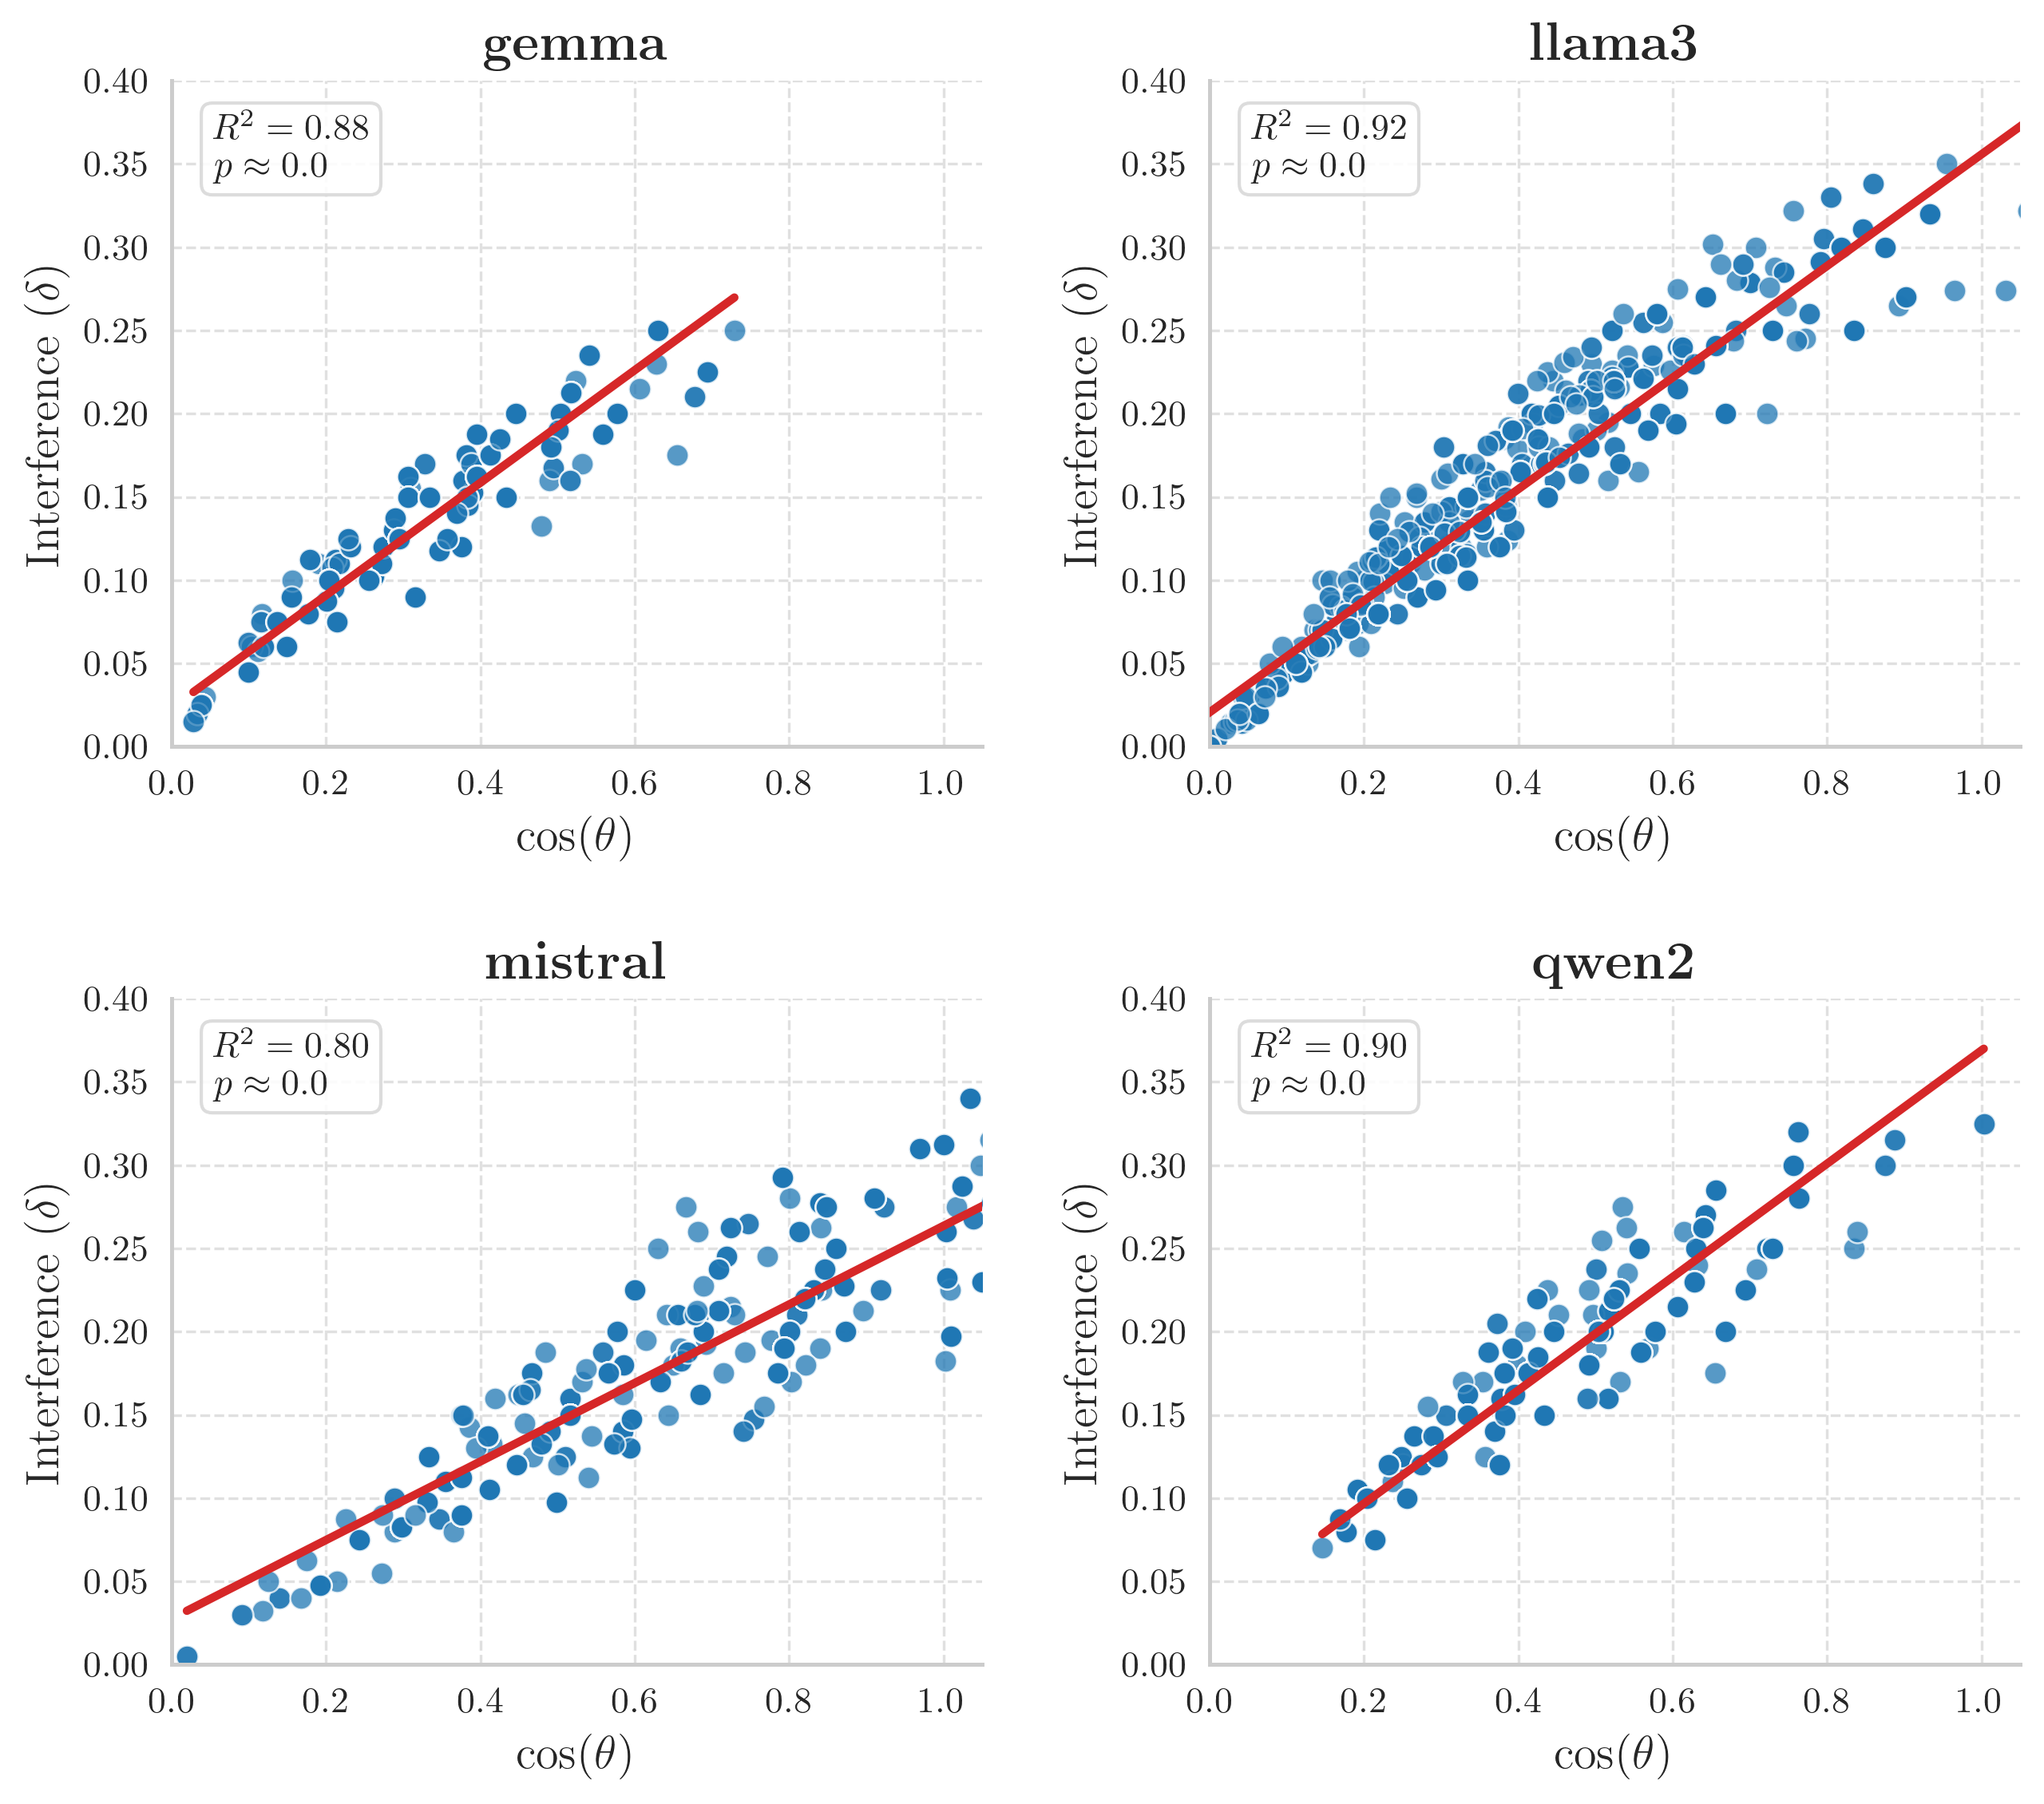

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ------------------------------------------------
# STYLE
# ------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,                      # Enable LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],  # Classic LaTeX font
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

df = pd.read_csv("llm_capability_results.csv")

# ------------------------------------------------
# COMPUTE TRIAL-LEVEL INTERFERENCE
# ------------------------------------------------

records = []

for model in df["model"].unique():

    P_A = df[(df.model==model) & (df.task=="prob_A")]["value"].values
    P_A_B = df[(df.model==model) & (df.task=="context_A_then_B")]["value"].values
    P_A_notB = df[(df.model==model) & (df.task=="prob_A_given_not_B")]["value"].values
    P_B = df[(df.model==model) & (df.task=="ambiguity")]["value"].values

    n = min(len(P_A), len(P_A_B), len(P_A_notB), len(P_B))

    for i in range(n):

        pa = P_A[i]
        pab = P_A_B[i]
        panb = P_A_notB[i]
        pb = P_B[i]

        classical = pab*pb + panb*(1-pb)

        delta = pa - classical

        K = 2*np.sqrt(pab*pb*panb*(1-pb))

        if True: #K > 0:
            costheta = delta/K

            records.append({
                "model": model,
                "delta": delta,
                "costheta": costheta
            })

interference_df = pd.DataFrame(records)

# ------------------------------------------------
# PLOTTING
# ------------------------------------------------

models = sorted(interference_df["model"].unique())

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.flatten()

# Color palette choices
scatter_color = "#1f77b4"  # Muted Blue
line_color = "#d62728"     # Brick Red

for i, model in enumerate(models):

    data = interference_df[interference_df.model==model]

    x = data["costheta"].values
    y = data["delta"].values

    ax = axes[i]

    # professional scatter with edgecolors to differentiate overlapping points
    ax.scatter(
        x,
        y,
        s=45,
        color=scatter_color,
        edgecolors="white",
        linewidths=0.6,
        alpha=0.75,
        zorder=2
    )

    # regression line
    result = linregress(x, y)

    xs = np.linspace(min(x), max(x), 100)
    ys = result.slope*xs + result.intercept

    ax.plot(xs, ys, color=line_color, linewidth=2.5, zorder=3)

    # clean, boxed statistics avoiding data overlap
    # stats_text = rf"$R^2 = {result.rvalue**2:.2f}$" + "\n" + rf"$p = {result.pvalue:.2e}$"
    
    # Format the p-value to scientific notation, then split into mantissa and exponent
    mantissa, exp = f"{result.pvalue:.2e}".split('e')

    # Construct the string using LaTeX \times 10^{exponent}
    stats_text = (
        rf"$R^2 = {result.rvalue**2:.2f}$" + "\n" + 
        rf"$p \approx 0.0$" # {mantissa} \times 10^{{{int(exp)}}}$"
    )

    bbox_props = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.85", alpha=0.9)
    ax.text(
        0.05,
        0.95,
        stats_text,
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=11,
        bbox=bbox_props,
        zorder=4
    )

    # Use bold for titles in LaTeX
    ax.set_title(rf"\textbf{{{model}}}")

    # Labels
    ax.set_xlabel(r"$\cos(\theta)$")
    ax.set_ylabel(r"Interference ($\delta$)")
    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 0.4)
    # Clean grid: softer dashed lines, hidden behind data (zorder=0)
    ax.grid(True, axis="both", linestyle="--", color="0.88", linewidth=0.8, zorder=0)

    # Remove right and top spines for a cleaner aesthetic
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout(pad=2.0)

plt.savefig("figure_interference_structure.pdf", bbox_inches="tight")
plt.show()

In [26]:
N=int(len(list(df.groupby("model"))[0][1])/14)

In [15]:
result

LinregressResult(slope=np.float64(0.3401505883622168), intercept=np.float64(0.028795505625408058), rvalue=np.float64(0.951264969000953), pvalue=np.float64(0.0), stderr=np.float64(0.0034904642899512978), intercept_stderr=np.float64(0.0015463696528298593))

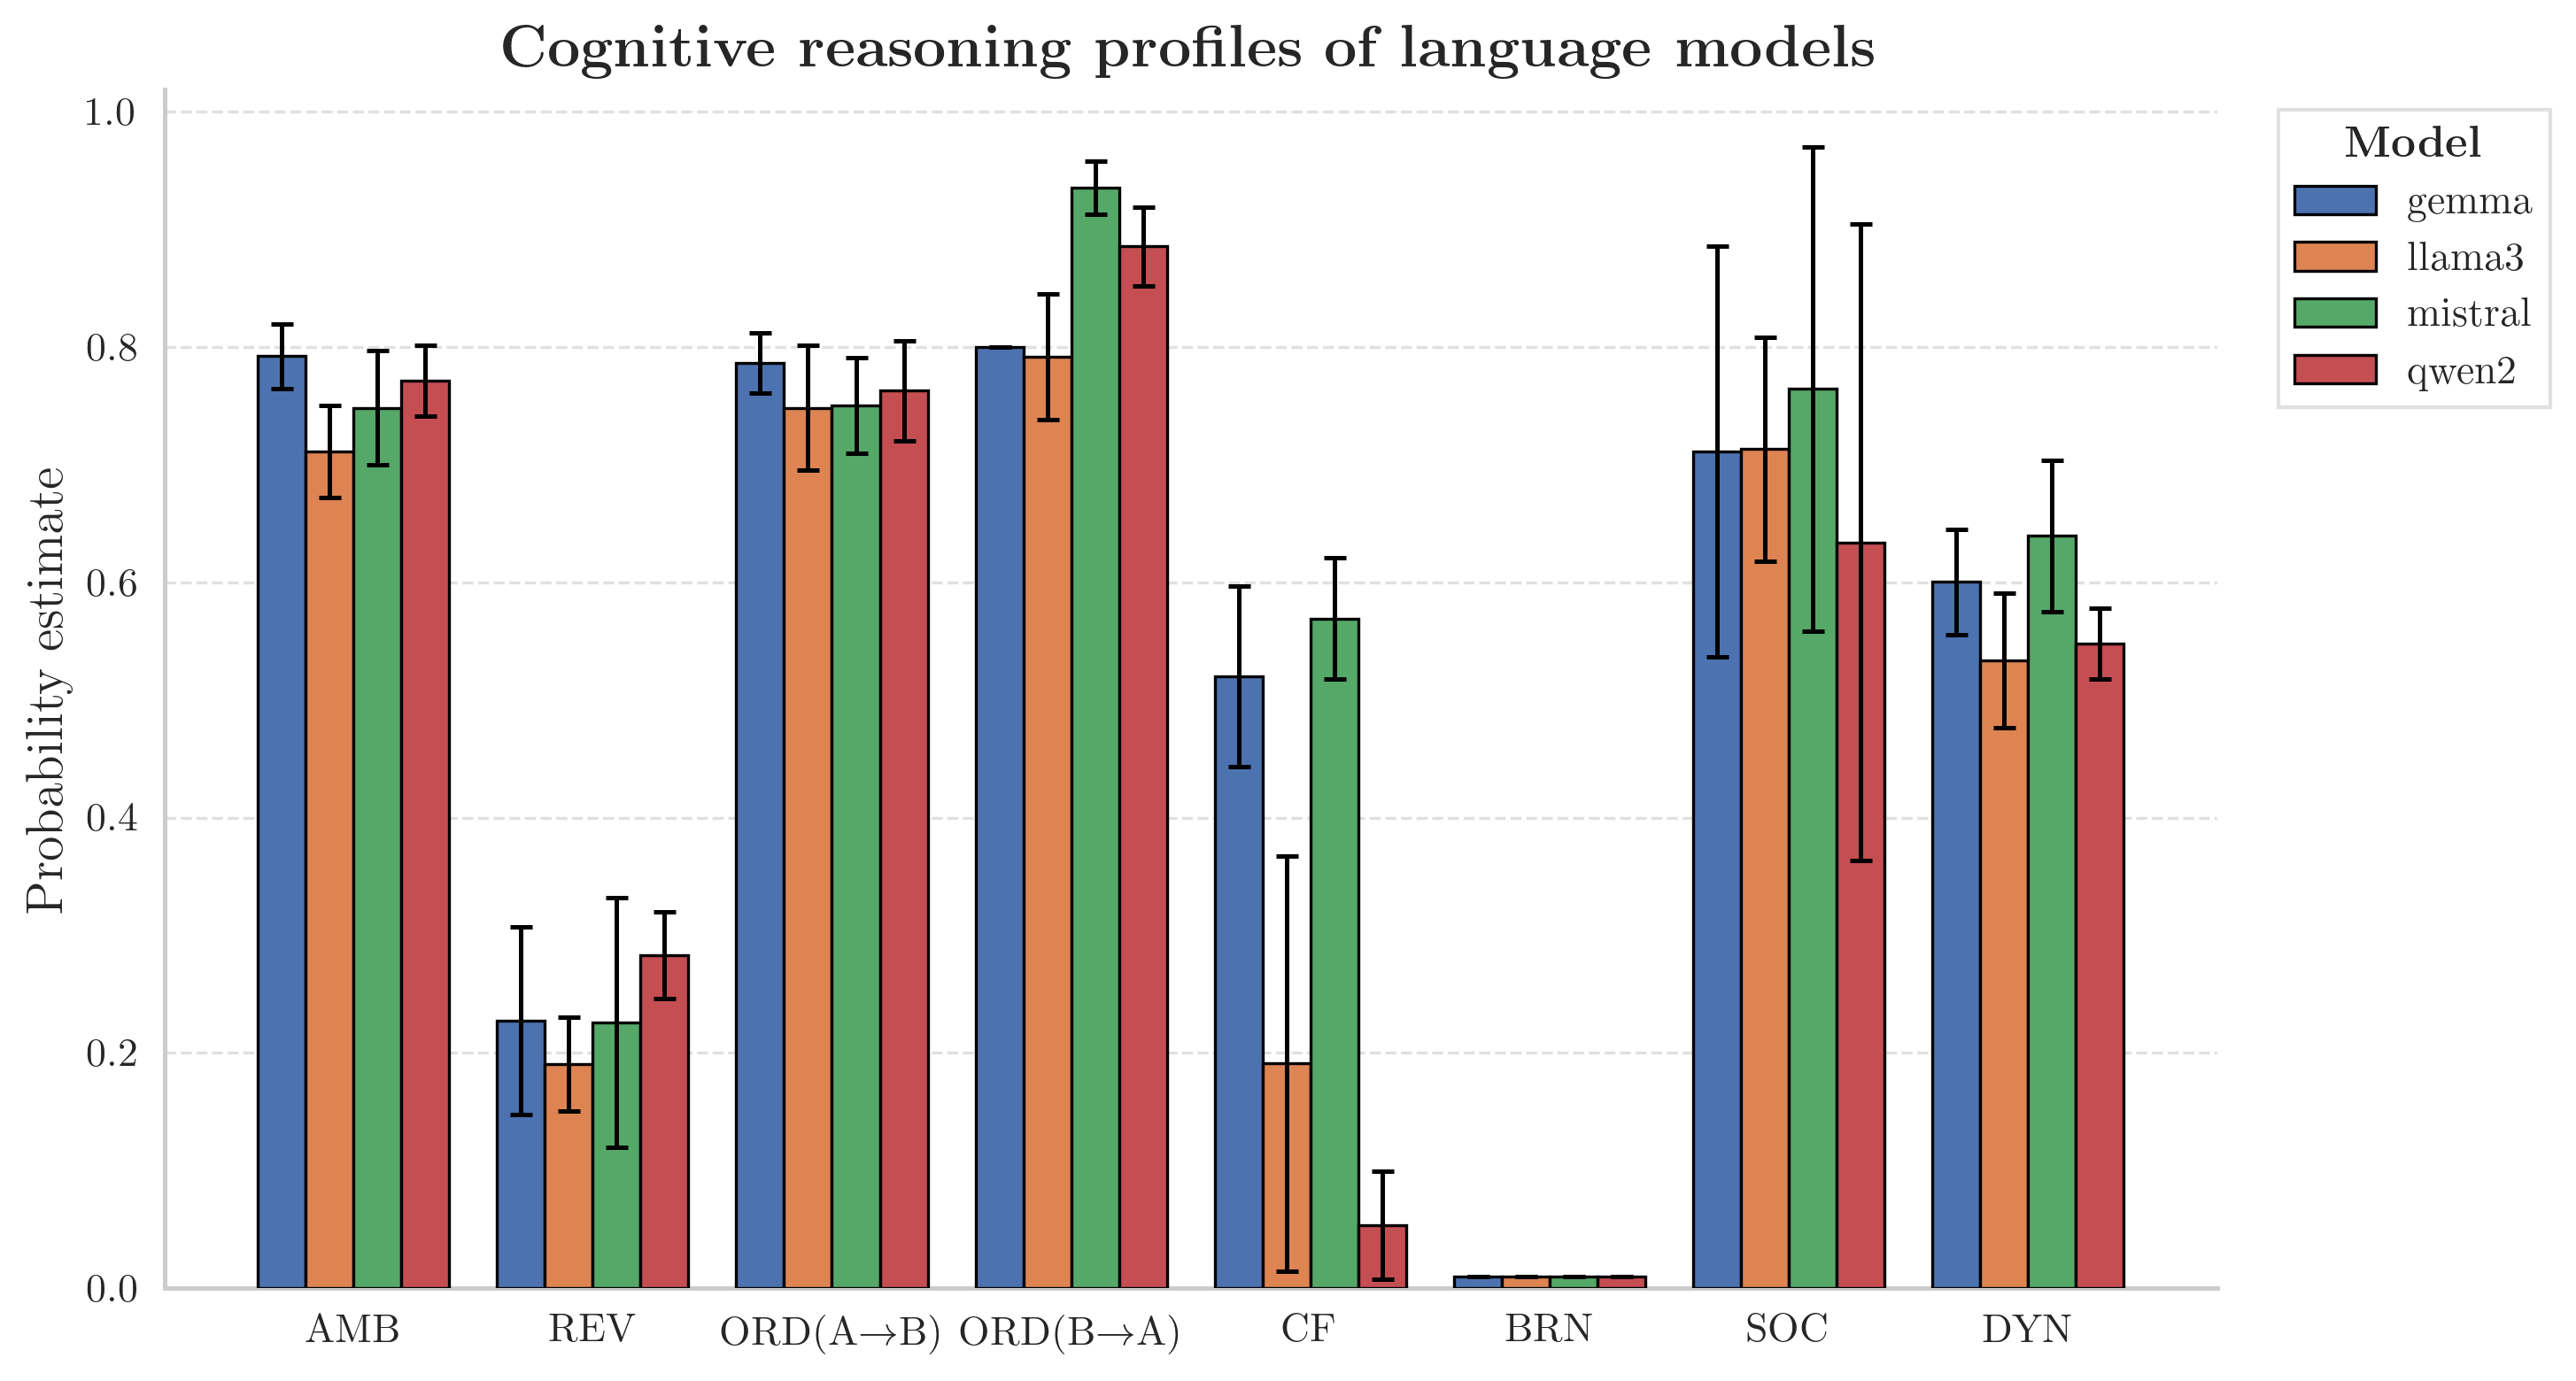

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# STYLE
# ------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,                      # Enable true LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],  # Classic LaTeX font
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

summary = pd.read_csv("summary.csv")
summary.columns = summary.columns.str.strip()

# ------------------------------------------------
# TASK SHORTHANDS
# ------------------------------------------------

# Converted standard arrows to LaTeX math arrows to prevent rendering errors
task_labels = {
    "ambiguity": r"AMB",
    "revision": r"REV",
    "context_A_then_B": r"ORD(A$\rightarrow$B)",
    "context_B_then_A": r"ORD(B$\rightarrow$A)",
    "conjunction_fallacy": r"CF",
    "base_rate_neglect": r"BRN",
    "social": r"SOC",
    "dynamics": r"DYN"
}

tasks = [t for t in task_labels if t in summary["task"].unique()]
models = sorted(summary["model"].unique())

# ------------------------------------------------
# PLOT
# ------------------------------------------------

x = np.arange(len(tasks))

# Dynamically size width based on the number of models to ensure they fit cleanly
width = 0.8 / len(models) 

fig, ax = plt.subplots(figsize=(10, 5.5))

# Professional color palette (colorblind-friendly muted tones)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

for i, model in enumerate(models):

    data = summary[summary["model"] == model]

    means = []
    errors = []

    for task in tasks:
        row = data[data["task"] == task]
        if not row.empty:
            means.append(row["mean"].values[0])
            errors.append(row["sem"].values[0] *np.sqrt(N))  # Convert SEM to standard deviation for error bars
        else:
            means.append(0)
            errors.append(0)

    # Offset x positions for grouped bars
    x_pos = x + i * width - (len(models) - 1) * width / 2

    ax.bar(
        x_pos,
        means,
        width,
        label=model,
        color=colors[i % len(colors)],
        edgecolor="black",       # Crisp borders for scientific plotting
        linewidth=0.8,
        zorder=3                 # Ensure bars render on top of the grid
    )

    # Add error bars separately to give them distinct styling
    ax.errorbar(
        x_pos,
        means,
        yerr=errors,
        fmt="none",
        ecolor="black",
        elinewidth=1.2,
        capsize=3,
        capthick=1.2,
        zorder=4
    )

# ------------------------------------------------
# AXES & FORMATTING
# ------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels([task_labels[t] for t in tasks])

ax.set_ylabel("Probability estimate")
ax.set_title(r"\textbf{Cognitive reasoning profiles of language models}")

# Clean legend
ax.legend(
    title=r"\textbf{Model}", 
    frameon=True, 
    edgecolor="0.85", 
    fancybox=False,
    loc="upper left",
    bbox_to_anchor=(1.02, 1) # Moves legend outside the plot to prevent data overlap
)

# Subtle dashed grid lines behind the data
ax.grid(axis="y", linestyle="--", color="0.88", linewidth=0.8, zorder=0)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Use tight_layout with a small pad to accommodate the external legend
plt.tight_layout(pad=1.5)

plt.savefig("figure_task_profile.pdf", bbox_inches="tight")
plt.show()

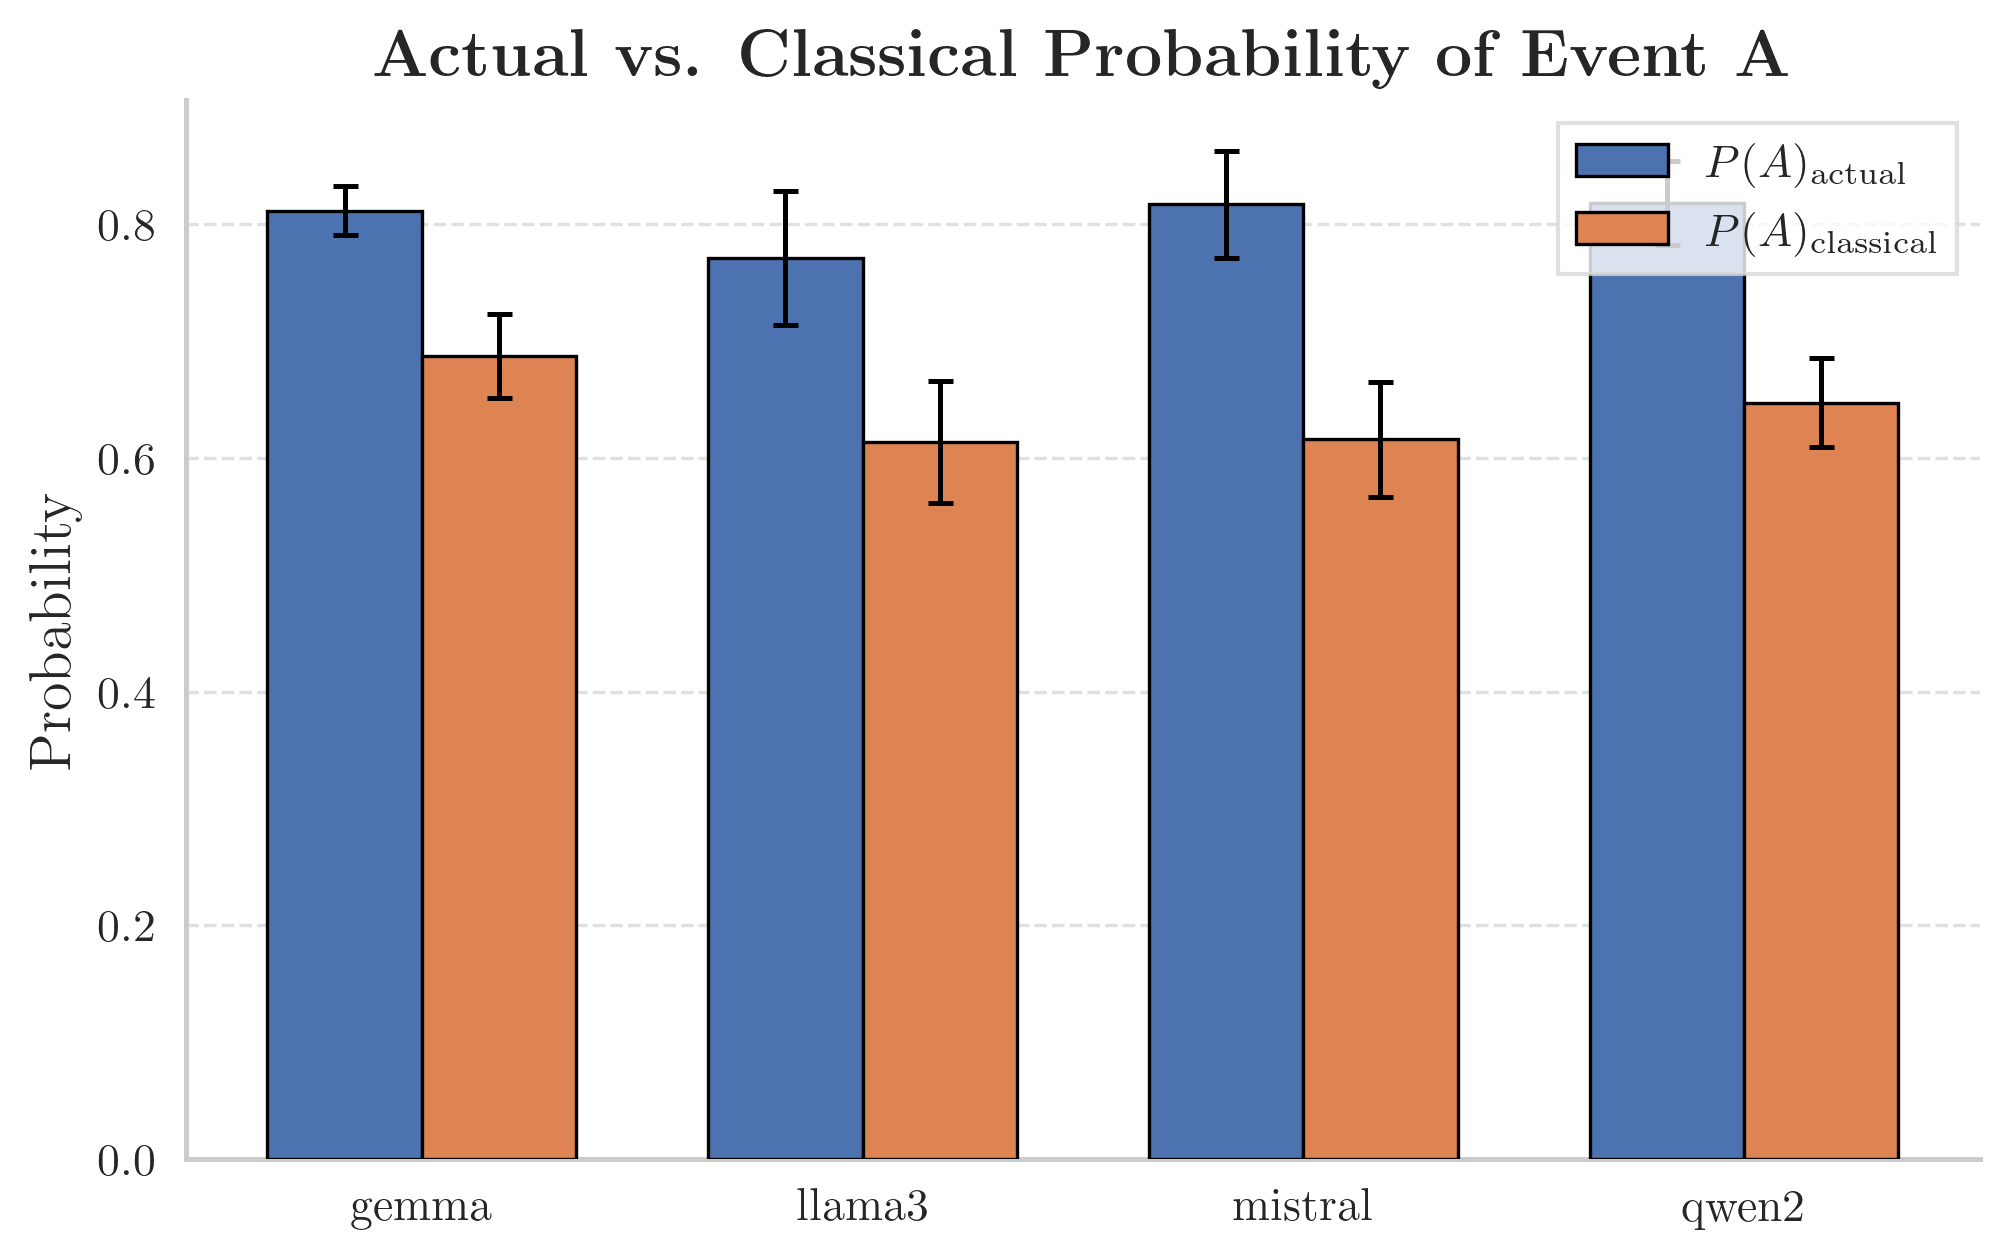

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# STYLE
# ------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,                      # Enable true LaTeX rendering
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],  # Classic LaTeX font
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
})

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------

ltp = pd.read_csv("ltp_violation.csv")
ltp.columns = ltp.columns.str.strip()

# ------------------------------------------------
# SET MODEL ORDER & EXTRACT COLUMNS
# ------------------------------------------------

# Enforce the specific model order
desired_order = ["gemma", "llama3", "mistral", "qwen2"]
ltp["model"] = pd.Categorical(ltp["model"], categories=desired_order, ordered=True)

# Sort the dataframe by the new categorical order and reset the index
ltp = ltp.sort_values("model").reset_index(drop=True)

models = ltp["model"]

# Map exact CSV headers for the actual probabilities
p_actual = ltp["P_A_mean"]
err_actual = ltp["P_A_sem"] *np.sqrt(N)

# Map exact CSV headers for the classical probabilities
p_classical = ltp["classical_mean"]
err_classical = ltp["classical_sem"]*np.sqrt(N)

# ------------------------------------------------
# PLOT
# ------------------------------------------------

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))

# Professional color palette
color_actual = "#4C72B0"
color_classical = "#DD8452"

# Actual Bars
ax.bar(
    x - width/2,
    p_actual,
    width,
    label=r"$P(A)_{\mathrm{actual}}$",
    color=color_actual,
    edgecolor="black",       
    linewidth=0.8,
    zorder=3                 
)

# Actual Error Bars
ax.errorbar(
    x - width/2,
    p_actual,
    yerr=err_actual,
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    zorder=4
)

# Classical Bars
ax.bar(
    x + width/2,
    p_classical,
    width,
    label=r"$P(A)_{\mathrm{classical}}$",
    color=color_classical,
    edgecolor="black",
    linewidth=0.8,
    zorder=3
)

# Classical Error Bars
ax.errorbar(
    x + width/2,
    p_classical,
    yerr=err_classical,
    fmt="none",
    ecolor="black",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    zorder=4
)

# ------------------------------------------------
# AXES & FORMATTING
# ------------------------------------------------

ax.set_xticks(x)
# Capitalize the labels for a more formal look (optional, but standard)
ax.set_xticklabels(models) #[m.capitalize() for m in models])

ax.set_ylabel(r"Probability")
ax.set_title(r"\textbf{Actual vs. Classical Probability of Event A}")

# Clean legend formatting
ax.legend(
    frameon=True,
    edgecolor="0.85",
    fancybox=False,
    loc="upper right",
    fontsize=11
)

# Subtle dashed grid lines layered behind the data
ax.grid(axis="y", linestyle="--", color="0.88", linewidth=0.8, zorder=0)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(pad=1.5)

plt.savefig("figure_ltp_violation_ordered.pdf", bbox_inches="tight")

plt.show()